In [ ]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 42.2 MB/s eta 0:00:00


In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
arquivo_edf = "chb24_01.edf"
raw = mne.io.read_raw_edf(arquivo_edf, preload=True)
raw

Extracting EDF parameters from chb24_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_308/2877399466.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(arquivo_edf, preload=True)


<RawEDF | chb24_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
print(raw.info)
print(raw.ch_names)
print(f"Taxa de amostragem: {raw.info['sfreq']} Hz")

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-01-25 16:26:28 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Taxa de amostragem: 256.0 Hz


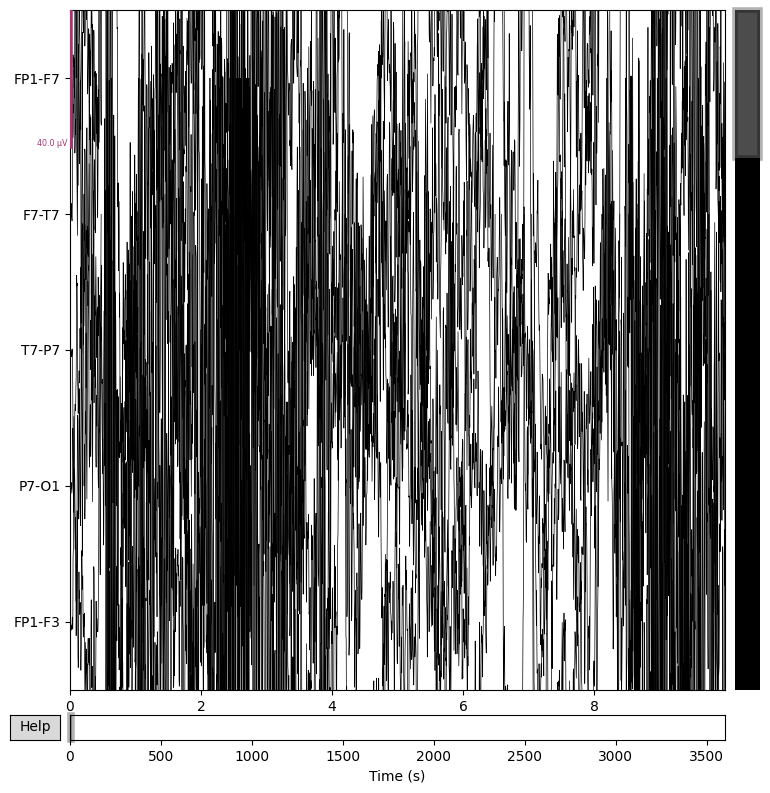

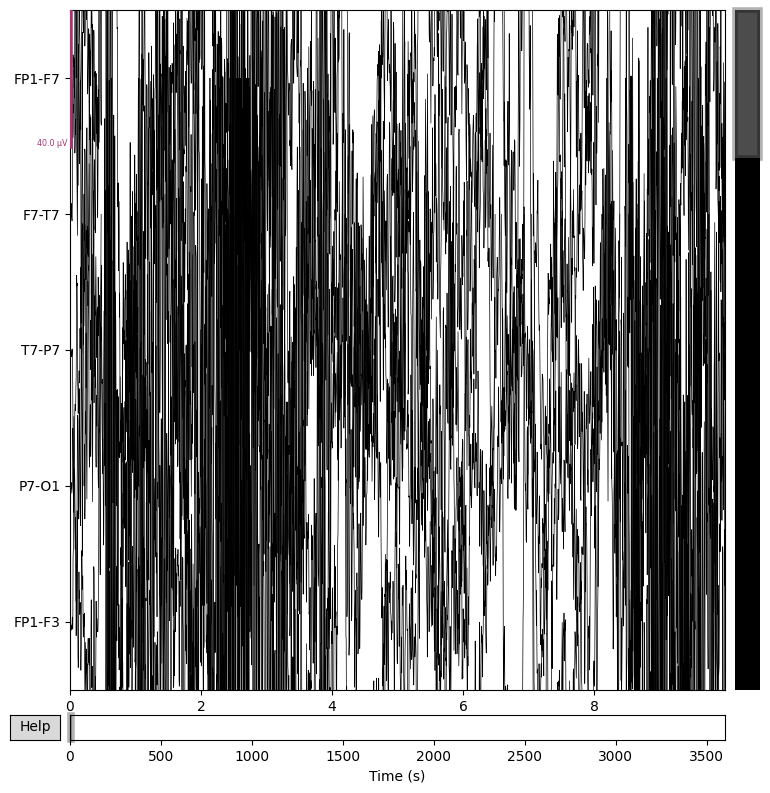

In [ ]:
raw.plot(duration=10, n_channels=5)

In [ ]:
data = raw.get_data()
data.shape

(23, 921600)

In [ ]:
print("Número de canais:", data.shape[0])
print("Número de amostras:", data.shape[1])

Número de canais: 23
Número de amostras: 921600


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



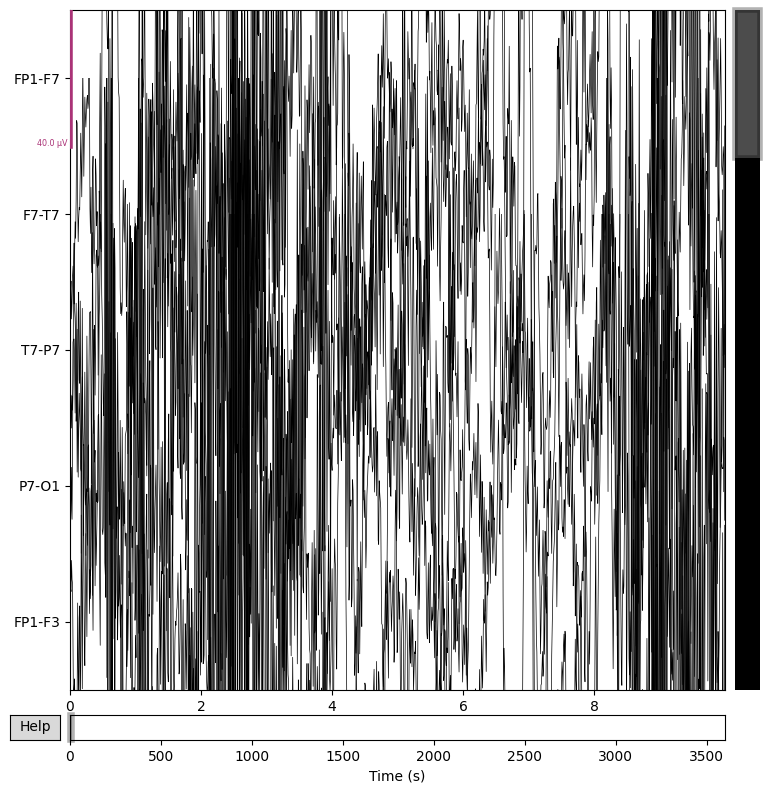

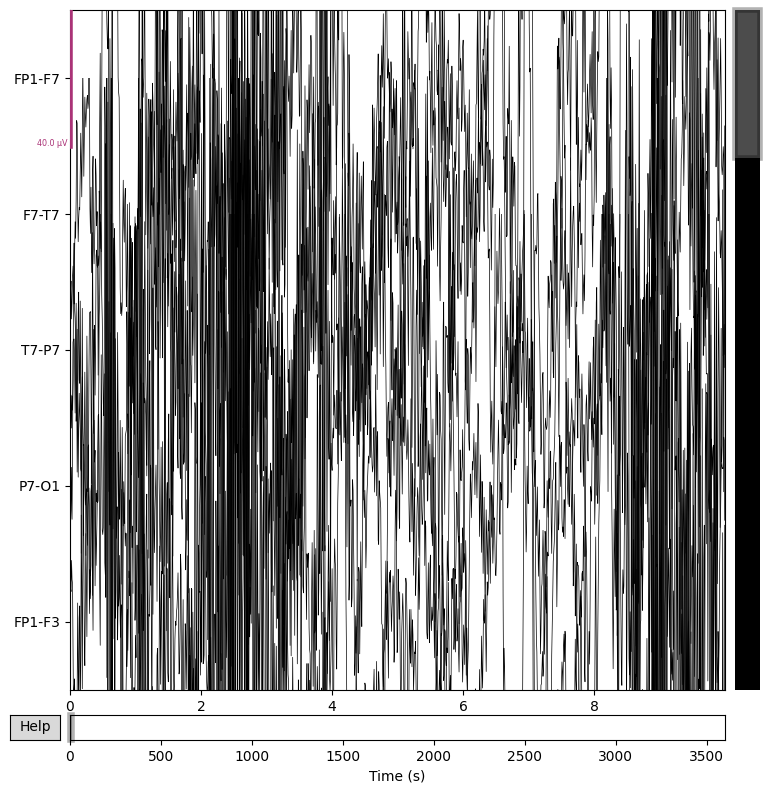

In [ ]:
raw_filtrado = raw.copy().filter(0.5, 40)
raw_filtrado.plot(duration=10, n_channels=5)

In [ ]:
data_filtrado = raw_filtrado.get_data()
data_filtrado.shape

(23, 921600)

In [ ]:
with open("chb24-summary.txt", "r") as f:
    conteudo = f.readlines()

for linha in conteudo[:40]:
    print(linha.strip())

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb24_01.edf
Number of Seizures in File: 2
Seizure Start Time: 480 seconds
Seizure End Time: 505 seconds
Seizure Start Time: 2451 seconds
Seizure End Time: 2476 seconds

File Name: chb24_03.edf
Number of Seizures in File: 2
Seizure Start Time: 231 seconds
Seizure End Time: 260 seconds


In [ ]:
seizure_intervals_sec = [
    (480, 505),
    (2451, 2476)
]

sfreq = raw.info["sfreq"]

In [ ]:
canal_idx = 0
signal = data_filtrado[canal_idx]

In [ ]:
time = np.arange(len(signal)) / sfreq

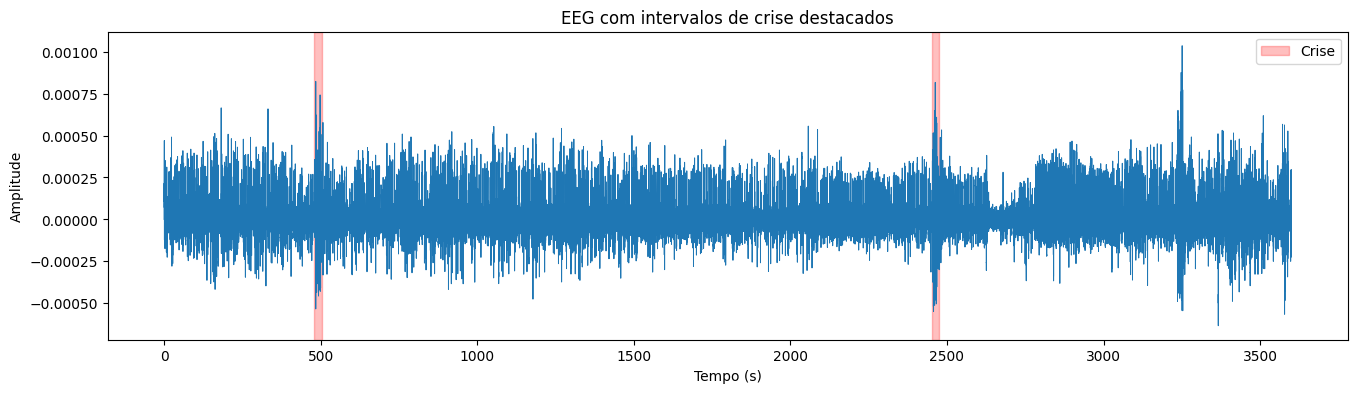

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(time, signal, linewidth=0.7)

for i,(start,end) in enumerate(seizure_intervals_sec):
    plt.axvspan(start, end, color="red", alpha=0.25,
                label="Crise" if i==0 else None)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG com intervalos de crise destacados")
plt.legend()
plt.show()

In [ ]:
window_size = 256
step = 128

windows = []

for start in range(0, data_filtrado.shape[1] - window_size, step):
    segment = data_filtrado[:, start:start + window_size]
    windows.append(segment)

windows = np.array(windows)
windows.shape

(7198, 23, 256)

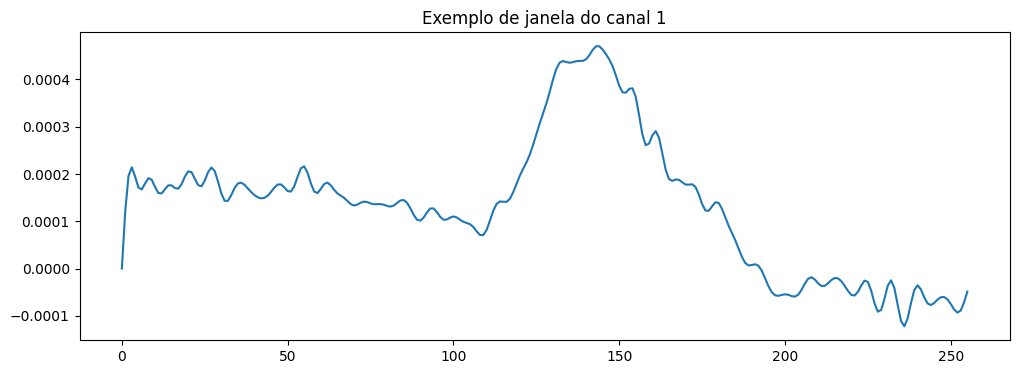

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(windows[0][0])
plt.title("Exemplo de janela do canal 1")
plt.show()

In [ ]:
print("Quantidade de janelas:", windows.shape[0])
print("Canais por janela:", windows.shape[1])
print("Pontos por janela:", windows.shape[2])

Quantidade de janelas: 7198
Canais por janela: 23
Pontos por janela: 256


# Aula 3

## Entendendo embedding com um exemplo simples

São Paulo → latitude e longitude:

(-23.55, -46.63)

👉 aqui já temos um embedding

Ou seja:
transformamos a cidade em um conjunto de números.


Adicionando mais informações:

- tamanho da cidade  
- população  
- densidade  


São Paulo → (-23.55, -46.63, 1521 km², 12 milhões)

## Conectando com o nosso problema

Aqui no EEG, fazemos a mesma coisa.

Cada janela do sinal é como uma "cidade".

E os números que calculamos:

- média  
- desvio padrão  
- máximo  
- mínimo  

são as características dessa janela.


## Ideia principal

Quanto melhor essa representação,
melhor o modelo consegue encontrar padrões.

👉 o modelo não entende o sinal diretamente  
👉 ele entende o embedding


In [ ]:
features = []

for window in windows:
    feat = []
    feat.extend(window.mean(axis=1))
    feat.extend(window.std(axis=1))
    feat.extend(window.max(axis=1))
    feat.extend(window.min(axis=1))
    features.append(feat)

X = np.array(features)
X.shape

(7198, 92)

In [ ]:
# lista onde vamos guardar o rótulo de cada janela
labels = []

# percorre o sinal da mesma forma que criamos as janelas
for start in range(0, data_filtrado.shape[1] - window_size, step):

    end = start + window_size  # fim da janela

    # converte índice → tempo (segundos)
    start_sec = start / sfreq
    end_sec = end / sfreq

    label = 0  # assume que é normal

    # verifica se a janela encosta em algum intervalo de crise
    for seizure_start, seizure_end in seizure_intervals_sec:

        overlap = (start_sec < seizure_end) and (end_sec > seizure_start)

        if overlap:
            label = 1  # marca como crise
            break

    labels.append(label)  # salva o rótulo da janela


# transforma em array
y = np.array(labels)

# resumo
print("Janelas totais:", len(y))
print("Janelas com crise:", y.sum())
print("Janelas normais:", (y == 0).sum())

Janelas totais: 7198
Janelas com crise: 102
Janelas normais: 7096


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(random_state=42)

modelo_arvore.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

# o modelo faz previsões em dados que ele nunca viu (teste)
y_pred = modelo_arvore.predict(X_test)

# comparando algumas previsões com o valor real
print("Comparação entre valor real e previsto:")
for i in range(10):
    print(f"Real: {y_test[i]} | Previsto: {y_pred[i]}")

# calculando a acurácia (quantos ele acertou no total)
acc = accuracy_score(y_test, y_pred)

print("\nAcurácia do modelo:", acc)

Comparação entre valor real e previsto:
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0

Acurácia do modelo: 0.9881944444444445


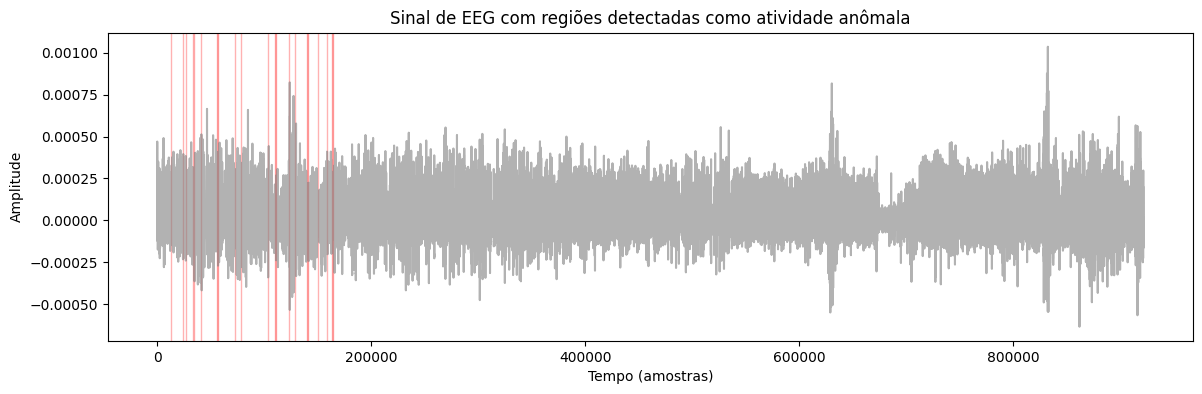

In [ ]:
import matplotlib.pyplot as plt

# sinal de um canal para visualização
signal = data_filtrado[0]

plt.figure(figsize=(14,4))
plt.plot(signal, color='gray', alpha=0.6)

# desenhando janelas classificadas
for i, pred in enumerate(y_pred):

    start = i * step
    end = start + window_size

    if pred == 1:  # classe anômala
        plt.axvspan(start, end, color='red', alpha=0.3)

plt.title("Sinal de EEG com regiões detectadas como atividade anômala")
plt.xlabel("Tempo (amostras)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
amostra = X_test[0].reshape(1, -1)

pred = modelo_arvore.predict(amostra)[0]

print("Predição da amostra:", pred)

Predição da amostra: 0


In [ ]:
from sklearn.neural_network import MLPClassifier

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=300,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [ ]:

y_pred_mlp = modelo_mlp.predict(X_test)


print("Comparação entre valor real e previsto (Rede Neural):")
for i in range(10):
    print(f"Real: {y_test[i]} | Previsto: {y_pred_mlp[i]}")


acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("\nAcurácia da rede neural:", acc_mlp)

Comparação entre valor real e previsto (Rede Neural):
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0

Acurácia da rede neural: 0.9847222222222223


In [ ]:
print("Árvore de decisão:", acc)
print("Rede neural:", acc_mlp)

Árvore de decisão: 0.9881944444444445
Rede neural: 0.9847222222222223


In [ ]:
X_dl = windows.transpose(0, 2, 1)  # amostras, tempo, canais
X_dl.shape

(7198, 256, 23)

In [ ]:
indice = 0
amostra_features = X_test[indice].reshape(1, -1)
pred_final = modelo_mlp.predict(amostra_features)[0]

print("Classe prevista:", pred_final)

Classe prevista: 0


In [ ]:
media_amostra = float(np.mean(X_test[indice]))
desvio_amostra = float(np.std(X_test[indice]))
max_amostra = float(np.max(X_test[indice]))
min_amostra = float(np.min(X_test[indice]))

print(media_amostra, desvio_amostra, max_amostra, min_amostra)

4.685934950027727e-07 6.80675586891798e-05 0.00010835898116730831 -0.00025604746965517057


In [ ]:
from openai import OpenAI
client = OpenAI(api_key="sk-proj-i5zRl4j4ZHOYPGl_ZL8EBw97Q6OSPTFVsV3uLLO64VhyA-7NNiKG4dNtT3BlbkFJfNnFUfylSum15y5IP7iP4ot3ptTyWK2mzETDRg96eTRVM_n5d3sMmnLkqdfCQVozjJg4kTgP4A")

prompt = f"""
Um modelo de inteligência artificial analisou um trecho de EEG.

Resumo da amostra:
- média: {media_amostra:.6f}
- desvio padrão: {desvio_amostra:.6f}
- valor máximo: {max_amostra:.6f}
- valor mínimo: {min_amostra:.6f}

Classe prevista: {pred_final}

Explique de forma simples o que isso significa.
"""

response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt
)

explicacao = response.output[0].content[0].text

print("\nExplicação da IA:\n")
print(explicacao)


Explicação da IA:

Esse trecho de EEG (eletroencefalograma) apresenta alguns dados estatísticos sobre a atividade elétrica do cérebro. Vamos quebrar os termos:

- **Média**: O valor médio da atividade elétrica é praticamente zero (0.000000), o que sugere que, em geral, as oscilações estão em torno de zero, ou seja, não há um padrão claro emergindo.
  
- **Desvio padrão**: O desvio padrão baixo (0.000068) indica que a maioria dos valores medidos está bem próxima da média, mostrando pouca variação na atividade elétrica.

- **Valor máximo e mínimo**: O valor máximo (0.000108) e o mínimo (-0.000256) mostram que houve algumas oscilações, mas que, em geral, são muito pequenas.

- **Classe prevista: 0**: Isso sugere que a inteligência artificial classificou essa amostra como pertencente a uma categoria específica, que neste caso é a classe 0. Sem contexto adicional, não sabemos exatamente o que essa classe significa, mas geralmente está relacionada a uma condição ou estado cerebral específic